# PGA-UNet — Test & Visualization

Chạy tuần tự: **Setup → Test → Visualization**

In [1]:
# ── Setup ─────────────────────────────────────────────────────────
%cd /content
import os, gdown

if not os.path.exists('Prompt-Guided-XRay-Segmentation'):
    !git clone -b TN_B_ON https://github.com/ThongLuc2k3/Prompt-Guided-XRay-Segmentation.git
else:
    !cd Prompt-Guided-XRay-Segmentation && git pull -q

!gdown 1X1SY8T63pdBPIdrv_3P0gKVwoLxCa5sW -O /content/dataset_BTXRD.zip -q
!unzip -oq /content/dataset_BTXRD.zip -d /content/
!rsync -a /content/dataset_BTXRD/ /content/Prompt-Guided-XRay-Segmentation/dataset_BTXRD/ 2>/dev/null

%cd /content/Prompt-Guided-XRay-Segmentation
!pip install -q tqdm opencv-python matplotlib gdown scipy

CKPT_ID   = '1eR4ULsOVbK-2GgC6SVaJqQF1et3AJ_M3'
CKPT_PATH = 'checkpoints/pga_unet_expB_best.pth'
os.makedirs('checkpoints', exist_ok=True)
if not os.path.exists(CKPT_PATH):
    gdown.download(f'https://drive.google.com/uc?id={CKPT_ID}', CKPT_PATH, quiet=False)
assert os.path.exists(CKPT_PATH)
print(f'\n✅ Setup xong  |  {os.path.getsize(CKPT_PATH)//1024} KB')

/content
Cloning into 'Prompt-Guided-XRay-Segmentation'...
remote: Enumerating objects: 186, done.
remote: Counting objects: 100% (124/124), done.
remote: Compressing objects: 100% (89/89), done.
remote: Total 186 (delta 64), reused 88 (delta 35), pack-reused 62 (from 1)
Receiving objects: 100% (186/186), 36.63 MiB | 14.90 MiB/s, done.
Resolving deltas: 100% (82/82), done.
/content/Prompt-Guided-XRay-Segmentation


Downloading...
From: https://drive.google.com/uc?id=1eR4ULsOVbK-2GgC6SVaJqQF1et3AJ_M3
To: /content/Prompt-Guided-XRay-Segmentation/checkpoints/pga_unet_expB_best.pth
100%|██████████| 11.9M/11.9M [00:00<00:00, 79.8MB/s]


✅ Setup xong  |  11615 KB


In [2]:
# ── Test: 3 prompt modes ─────────────────────────────────────────
import os, cv2, csv, glob
import numpy as np
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm
from scipy.ndimage import binary_erosion, distance_transform_edt

from dataset import BTXRD_Dataset
from models.networks.prompt_unet_2D import PGA_UNet

DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE = 512
IMG_DIR  = 'dataset_BTXRD/test/images'
JSON_DIR = 'dataset_BTXRD/test/annotations'
os.makedirs('results', exist_ok=True)

model = PGA_UNet(in_channels=1, n_classes=1, use_encoder_prompt=True).to(DEVICE)
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE, weights_only=True))
model.eval()
print(f'✅ Model loaded  device={DEVICE}')

def extract_lcc(m):
    if m.sum()==0: return m
    n,lbl,st,_=cv2.connectedComponentsWithStats(m.astype(np.uint8),8)
    return m if n<=1 else (lbl==(1+np.argmax(st[1:,cv2.CC_STAT_AREA]))).astype(np.float32)

def calc_hd95(pred, gt):
    p,g=pred.astype(bool),gt.astype(bool)
    if not p.any() and not g.any(): return 0.0
    if not p.any() or not g.any(): return float(IMG_SIZE)
    pe=p^binary_erosion(p); ge=g^binary_erosion(g)
    d1=distance_transform_edt(~ge)[pe]; d2=distance_transform_edt(~pe)[ge]
    return float(IMG_SIZE) if not len(d1) or not len(d2) else float(max(np.percentile(d1,95),np.percentile(d2,95)))

def calc_metrics(prob_np, gt_np):
    pm=extract_lcc((prob_np>0.5).astype(np.float32))
    gm=(gt_np>0.5).astype(np.float32); eps=1e-6
    tp=(pm*gm).sum(); fp=(pm*(1-gm)).sum(); fn=((1-pm)*gm).sum()
    hd95=calc_hd95(pm,gm)
    if gm.sum()==0 or pm.sum()==0: cbl=0.0
    else:
        ys,xs=np.where(gm>0.5); yp,xp=np.where(pm>0.5)
        cbl=float(np.clip(1.-np.sqrt((xp.mean()-xs.mean())**2+(yp.mean()-ys.mean())**2)/(np.sqrt((ys.max()-ys.min())**2+(xs.max()-xs.min())**2)+eps),0,1))
    return dict(dice=float((2*tp+eps)/(2*tp+fp+fn+eps)),iou=float((tp+eps)/(tp+fp+fn+eps)),
                precision=float((tp+eps)/(tp+fp+eps)),recall=float((tp+eps)/(tp+fn+eps)),
                hd95=hd95,cbl=cbl,mask=pm)

KEYS  = ['dice','iou','precision','recall','hd95','cbl']
HDRS  = ['Dice↑','IoU↑','Prec↑','Rec↑','HD95↓','CBL↑']
MODES = ['zoom_out','shift','mixed_7_3']
all_records = {}
csv_rows    = []

for mode in MODES:
    ds     = BTXRD_Dataset(IMG_DIR, JSON_DIR, img_size=IMG_SIZE, is_train=False, prompt_mode=mode)
    loader = DataLoader(ds, batch_size=1, shuffle=False, num_workers=0)
    recs   = []
    for img_t, mask_t, prompt_t in tqdm(loader, desc=f'[{mode}]'):
        gt_np = mask_t[0,0].numpy()
        with torch.no_grad():
            prob = torch.sigmoid(model(img_t.to(DEVICE), prompt_t.to(DEVICE)))[0,0].cpu().numpy()
        m = calc_metrics(prob, gt_np)
        recs.append(dict(img=img_t[0,0].numpy(), gt=gt_np, prob=prob,
                         prompt=prompt_t[0,0].numpy(), **{k:m[k] for k in KEYS}))
    all_records[mode] = recs
    m_avg = {k: np.mean([r[k] for r in recs]) for k in KEYS}
    csv_rows.append([mode]+[f'{m_avg[k]:.4f}' for k in KEYS]+[str(len(recs))])

# Bảng kết quả
bar='='*74
print(f'\n{bar}\n  PGA-UNet  |  N=248\n{bar}')
print(f"  {'Mode':<16}"+''.join(f'{h:>8}' for h in HDRS))
print(f"  {'-'*70}")
for row in csv_rows:
    print(f"  {row[0]:<16}"+''.join(f'{row[i+1]:>8}' for i in range(len(KEYS))))
print(bar)

with open('results/pga_extended_test_results.csv','w',newline='') as f:
    w=csv.writer(f); w.writerow(['mode']+KEYS+['N']); w.writerows(csv_rows)
print('\n✅ CSV: results/pga_extended_test_results.csv')

✅ Model loaded  device=cuda


[mixed_7_3]: 100%|██████████| 232/232 [00:33<00:00,  6.93it/s]


  PGA-UNet  |  N=248
  Mode               Dice↑    IoU↑   Prec↑    Rec↑   HD95↓    CBL↑
  ----------------------------------------------------------------------
  zoom_out          0.8768  0.7864  0.8621  0.9035  9.9125  0.9606
  shift             0.8456  0.7419  0.8444  0.8642 12.8515  0.9398
  mixed_7_3         0.8700  0.7763  0.8612  0.8918 10.7891  0.9549

✅ CSV: results/pga_extended_test_results.csv


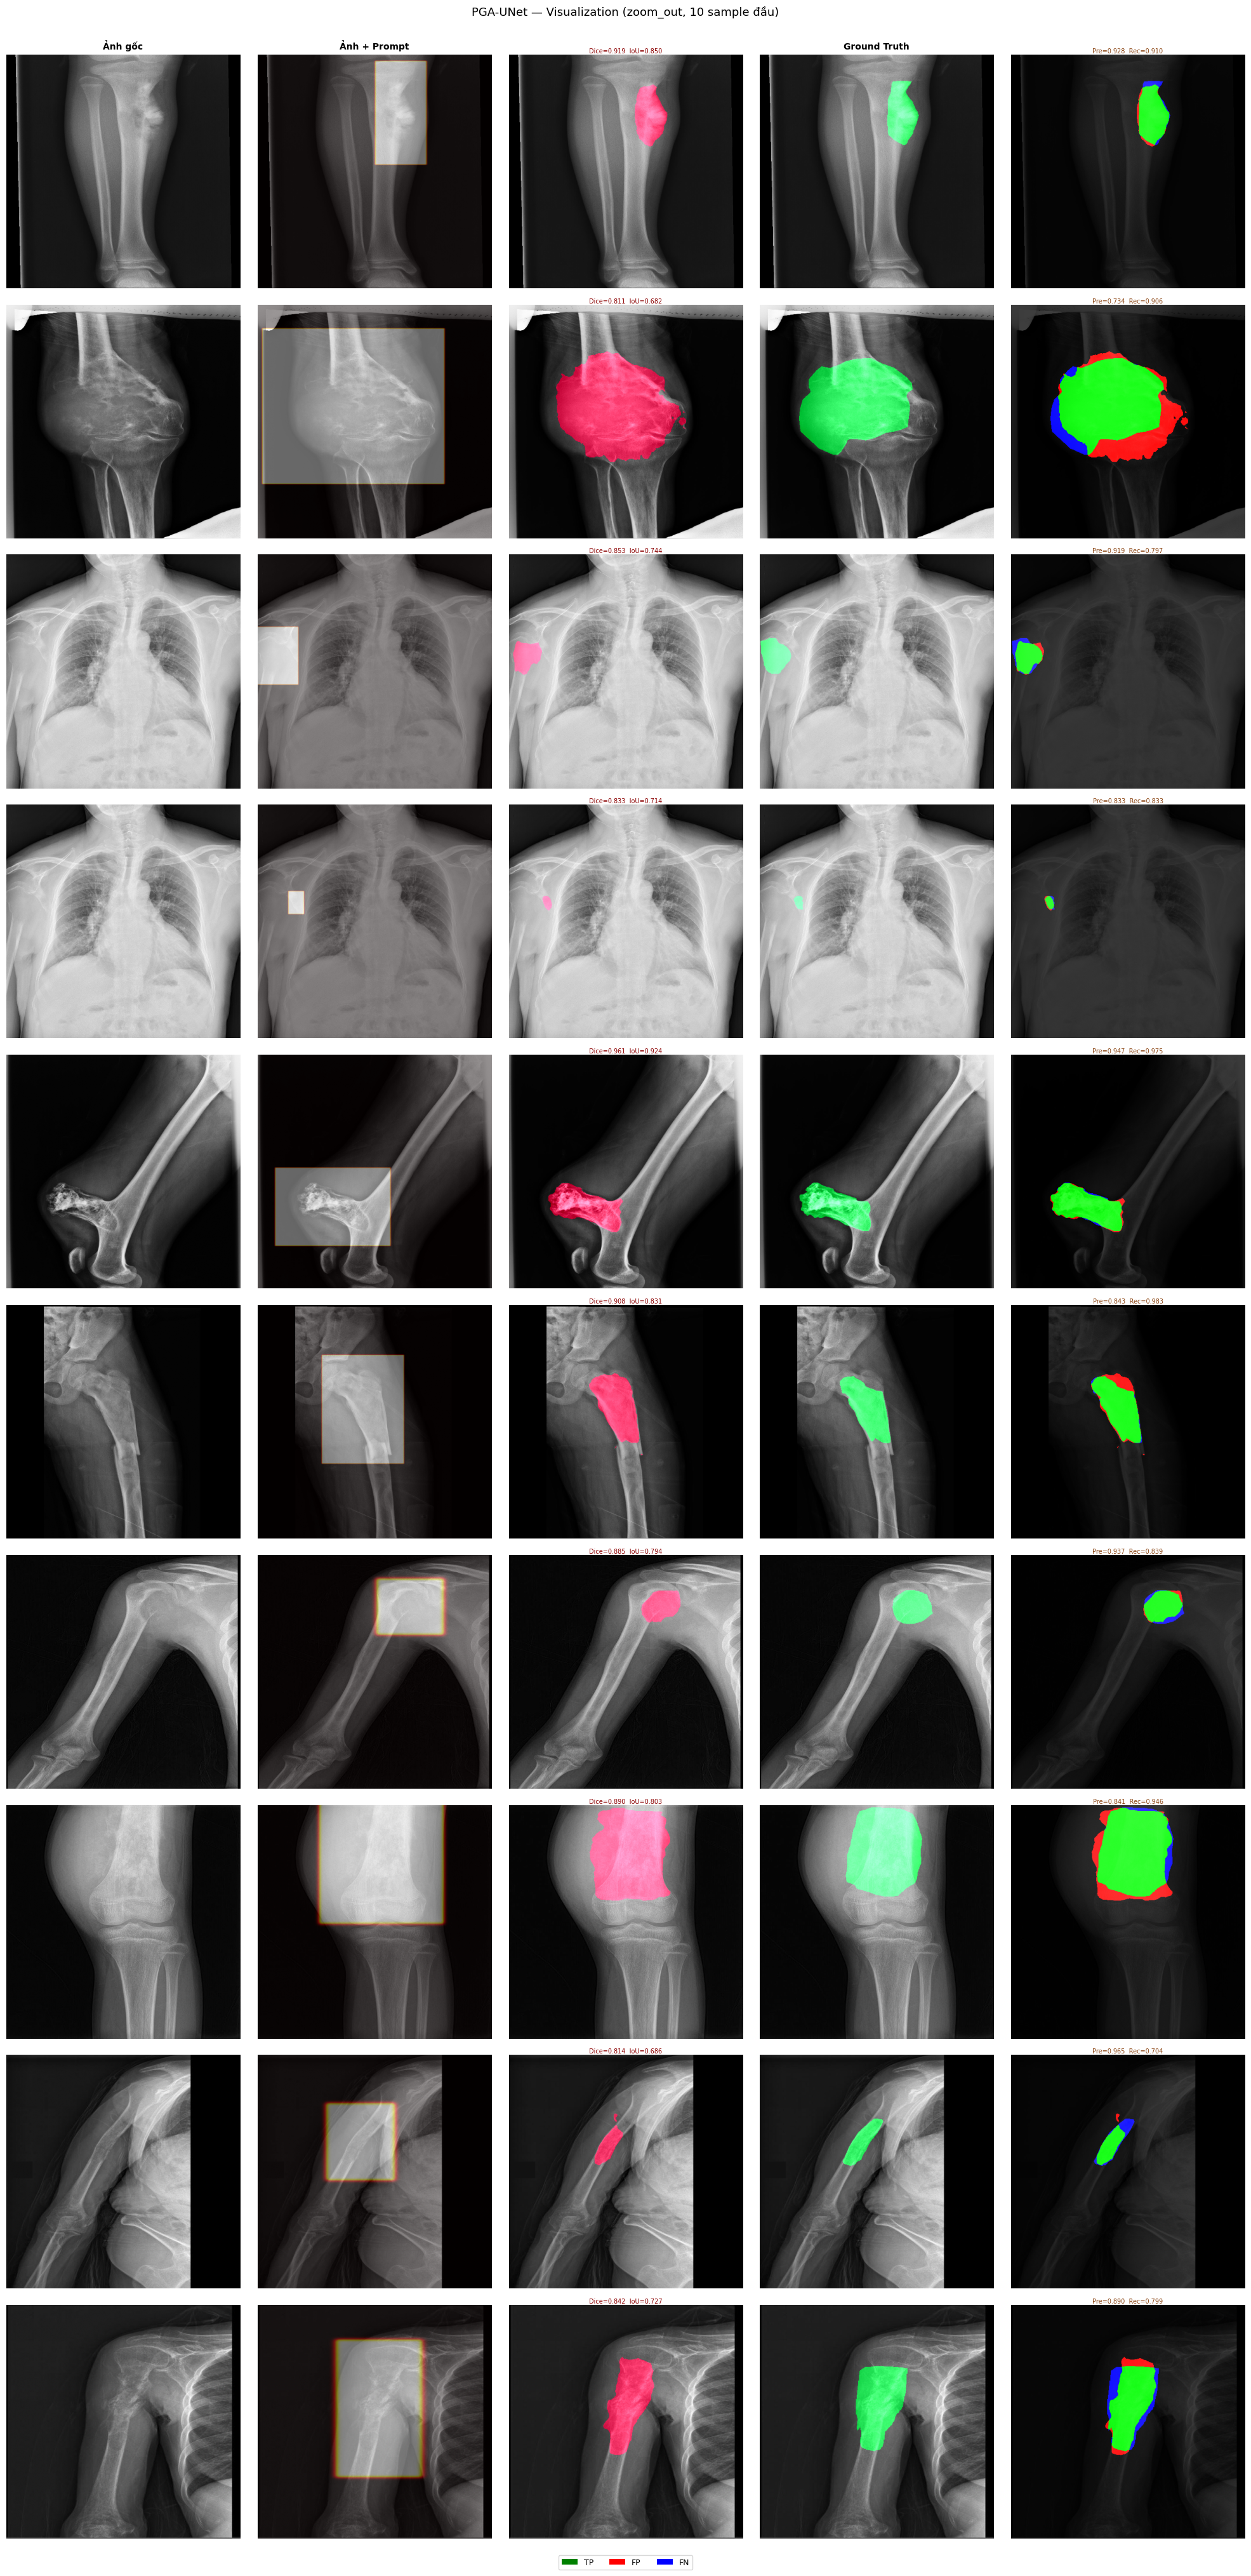

In [3]:
# ── Visualization: 10 sample đầu (zoom_out) — giống cell cuối PGA_Unet2D ──────
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from IPython.display import display as _ipy_display

assert 'all_records' in dir(), '❌ Chạy cell Test trước'

N_SHOW = 10
recs   = all_records['zoom_out'][:N_SHOW]

fig, axes = plt.subplots(N_SHOW, 5, figsize=(20, 4 * N_SHOW))
fig.suptitle(f'PGA-UNet — Visualization (zoom_out, {N_SHOW} sample đầu)', fontsize=13, y=1.001)

for ax, ct in zip(axes[0], ['Ảnh gốc', 'Ảnh + Prompt', 'Dự đoán', 'Ground Truth', 'TP/FP/FN']):
    ax.set_title(ct, fontsize=10, fontweight='bold')

for count, rec in enumerate(recs):
    img_np  = rec['img'] * 0.5 + 0.5          # denorm [-1,1] → [0,1]
    hm_np   = rec['prompt']
    gt_np   = (rec['gt'] > 0.5).astype(float)
    pred_np = (rec['prob'] > 0.5).astype(float)

    tp = (pred_np * gt_np).sum()
    fp = (pred_np * (1 - gt_np)).sum()
    fn = ((1 - pred_np) * gt_np).sum()
    e  = 1e-6
    dice = float((2*tp+e)/(2*tp+fp+fn+e))
    iou  = float((tp+e)/(tp+fp+fn+e))
    pre  = float((tp+e)/(tp+fp+e))
    rec_ = float((tp+e)/(tp+fn+e))

    row = axes[count]
    bg  = np.stack([img_np]*3, axis=-1)

    # Col 0: ảnh gốc
    row[0].imshow(img_np, cmap='gray', vmin=0, vmax=1)
    row[0].set_ylabel(f'#{count+1}  Dice={dice:.3f}', fontsize=8)

    # Col 1: ảnh + prompt heatmap
    row[1].imshow(img_np, cmap='gray', vmin=0, vmax=1)
    row[1].imshow(hm_np, cmap='hot', alpha=0.4, vmin=0, vmax=1)

    # Col 2: prediction overlay đỏ
    pr_ov = bg.copy()
    pr_ov[..., 0] = np.clip(pr_ov[..., 0] + pred_np * 0.55, 0, 1)
    pr_ov[..., 1] = np.clip(pr_ov[..., 1] - pred_np * 0.2,  0, 1)
    row[2].imshow(pr_ov)
    row[2].set_title(f'Dice={dice:.3f}  IoU={iou:.3f}', fontsize=7, color='darkred', pad=2)

    # Col 3: GT overlay xanh
    gt_ov = bg.copy()
    gt_ov[..., 1] = np.clip(gt_ov[..., 1] + gt_np * 0.55, 0, 1)
    gt_ov[..., 0] = np.clip(gt_ov[..., 0] - gt_np * 0.2,  0, 1)
    row[3].imshow(gt_ov)

    # Col 4: TP/FP/FN
    inter = bg.copy() * 0.25
    inter[..., 1] = np.clip(inter[..., 1] + pred_np * gt_np * 0.9,      0, 1)   # TP xanh
    inter[..., 0] = np.clip(inter[..., 0] + pred_np * (1-gt_np) * 1.0,  0, 1)   # FP đỏ
    inter[..., 2] = np.clip(inter[..., 2] + (1-pred_np) * gt_np * 1.0,  0, 1)   # FN xanh lam
    row[4].imshow(inter)
    row[4].set_title(f'Pre={pre:.3f}  Rec={rec_:.3f}', fontsize=7, color='saddlebrown', pad=2)

    for ax in row:
        ax.axis('off')

fig.legend(
    handles=[Patch(facecolor='green', label='TP'),
             Patch(facecolor='red',   label='FP'),
             Patch(facecolor='blue',  label='FN')],
    loc='lower center', ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.01)
)
plt.tight_layout()
_ipy_display(fig)
plt.close(fig)
